Fetching NASA data...
Fetching current weather...
Fetching weather data from OpenWeather...
Status: 200
✅ Cloud cover: 17%, Temperature: 29.05°C
Cloud cover: 17%, Temperature: 29.05°C

=== Summary ===
Average Daily Generation: 4.24 kWh/day
Total Monthly Generation: 131.32 kWh
Estimated Monthly Cost Savings: ₹787.94

Predicted Generation for Next 7 Days (kWh/day):
[6.77 6.93 7.09 7.25 7.4  7.56 7.72]


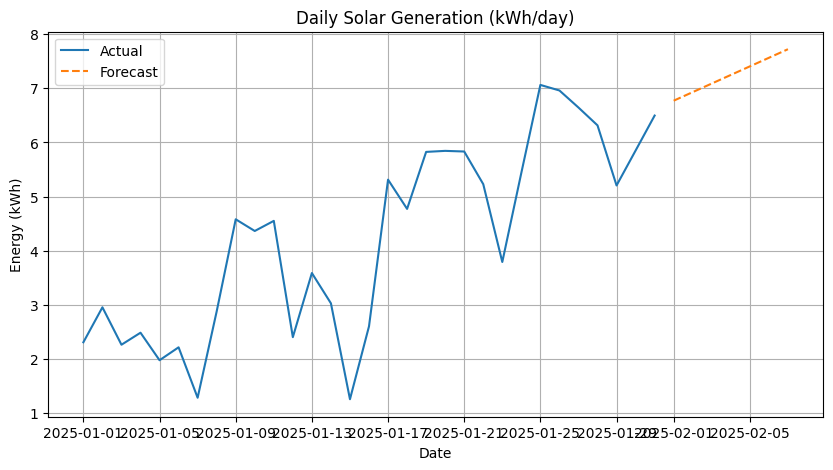

In [1]:
import requests
import pandas as pd
import datetime
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
LAT = 26.890937   # Example: Bangalore
LON = 81.073652
START = "20250101"
END = "20250131"
OPENWEATHER_KEY = "[REDACTED]"  # <-- put your key here
PANEL_EFFICIENCY = 0.18  # 18%
PANEL_AREA = 10  # m²

# ---------------- NASA POWER API ----------------
def get_nasa_data(lat, lon, start, end):
    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters=ALLSKY_SFC_SW_DWN&community=RE&longitude={lon}&latitude={lat}"
        f"&start={start}&end={end}&format=JSON"
    )
    r = requests.get(url)
    data = r.json()
    df = pd.DataFrame(data['properties']['parameter']['ALLSKY_SFC_SW_DWN'].items(),
                      columns=['date', 'irradiance_kWh_m2_day'])
    df['date'] = pd.to_datetime(df['date'])
    return df

# ---------------- OPENWEATHER API ----------------
def get_weather(lat, lon, key):
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={key}&units=metric"
    print(f"Fetching weather data from OpenWeather...")
    r = requests.get(url)
    print(f"Status: {r.status_code}")
    
    try:
        data = r.json()
    except Exception as e:
        print("❌ Error reading response:", e)
        return 0, 25  # fallback
    
    # Defensive parsing
    clouds = data.get('clouds', {}).get('all', 0)
    temp = data.get('main', {}).get('temp', 25)
    
    # If the response had a problem message, show it
    if "message" in data:
        print("⚠️ API message:", data["message"])
    
    print(f"✅ Cloud cover: {clouds}%, Temperature: {temp}°C")
    return clouds, temp


# ---------------- CALCULATION ----------------
def calculate_generation(df, cloud_cover):
    # Adjust irradiance by cloud cover
    df['adjusted_irradiance'] = df['irradiance_kWh_m2_day'] * (1 - cloud_cover / 100)
    # Calculate energy generation (kWh/day)
    df['generation_kWh'] = df['adjusted_irradiance'] * PANEL_AREA * PANEL_EFFICIENCY
    return df

# ---------------- COST ESTIMATION ----------------
def estimate_cost(df, usage_type='residential'):
    rate = 6 if usage_type == 'residential' else 10  # ₹/kWh
    df['cost_savings'] = df['generation_kWh'] * rate
    return df

# ---------------- SIMPLE FORECAST ----------------
def forecast_generation(df):
    df = df.reset_index(drop=True)
    X = np.arange(len(df)).reshape(-1, 1)
    y = df['generation_kWh'].values
    model = LinearRegression().fit(X, y)
    future_days = np.arange(len(df), len(df) + 7).reshape(-1, 1)
    preds = model.predict(future_days)
    return preds

# ---------------- RUN ALL ----------------
print("Fetching NASA data...")
solar_df = get_nasa_data(LAT, LON, START, END)

print("Fetching current weather...")
cloud_cover, temp = get_weather(LAT, LON, OPENWEATHER_KEY)
print(f"Cloud cover: {cloud_cover}%, Temperature: {temp}°C")

solar_df = calculate_generation(solar_df, cloud_cover)
solar_df = estimate_cost(solar_df)

# Summary
daily_avg = solar_df['generation_kWh'].mean()
monthly_total = solar_df['generation_kWh'].sum()
cost_month = solar_df['cost_savings'].sum()

print("\n=== Summary ===")
print(f"Average Daily Generation: {daily_avg:.2f} kWh/day")
print(f"Total Monthly Generation: {monthly_total:.2f} kWh")
print(f"Estimated Monthly Cost Savings: ₹{cost_month:.2f}")

# Forecast next 7 days
preds = forecast_generation(solar_df)
print("\nPredicted Generation for Next 7 Days (kWh/day):")
print(preds.round(2))

# Plot
plt.figure(figsize=(10,5))
plt.plot(solar_df['date'], solar_df['generation_kWh'], label='Actual')
plt.plot(pd.date_range(solar_df['date'].iloc[-1], periods=8, freq='D')[1:], preds, label='Forecast', linestyle='--')
plt.title("Daily Solar Generation (kWh/day)")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid()
plt.show()



In [3]:
import requests

key = "[REDACTED]"  # your key
lat, lon = 12.9716, 77.5946

r = requests.get(f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={key}&units=metric")
print("Status:", r.status_code)
print("Response:", r.text)


Status: 200
Response: {"coord":{"lon":77.5937,"lat":12.9719},"weather":[{"id":802,"main":"Clouds","description":"scattered clouds","icon":"03d"}],"base":"stations","main":{"temp":26.63,"feels_like":26.63,"temp_min":24.54,"temp_max":27,"pressure":1014,"humidity":64,"sea_level":1014,"grnd_level":917},"visibility":8000,"wind":{"speed":8.94,"deg":258,"gust":22.35},"clouds":{"all":40},"dt":1762063460,"sys":{"type":2,"id":2017753,"country":"IN","sunrise":1762044210,"sunset":1762086166},"timezone":19800,"id":1277333,"name":"Bengaluru","cod":200}


In [ ]:
import requests
import pandas as pd
import datetime
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
OPENWEATHER_KEY = "[REDACTED]"  # <-- your key
PANEL_EFFICIENCY = 0.18  # 18%
PANEL_AREA = 10  # m²

# ---------------- 🔹 Integrated Feature: Get Lat/Lon from Location ----------------
def get_lat_lon_from_location(location_name, api_key):
    """Use OpenWeather Geocoding API to get latitude and longitude from location name"""
    url = f"http://api.openweathermap.org/geo/1.0/direct?q={location_name}&limit=1&appid={api_key}"
    r = requests.get(url)
    data = r.json()
    if len(data) == 0:
        raise ValueError("❌ Location not found. Please try another city name.")
    lat = data[0]['lat']
    lon = data[0]['lon']
    print(f"✅ Found location: {location_name} -> Latitude: {lat}, Longitude: {lon}")
    return lat, lon


# ---------------- NASA POWER API ----------------
def get_nasa_data(lat, lon, start, end):
    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters=ALLSKY_SFC_SW_DWN&community=RE&longitude={lon}&latitude={lat}"
        f"&start={start}&end={end}&format=JSON"
    )
    r = requests.get(url)
    data = r.json()
    df = pd.DataFrame(data['properties']['parameter']['ALLSKY_SFC_SW_DWN'].items(),
                      columns=['date', 'irradiance_kWh_m2_day'])
    df['date'] = pd.to_datetime(df['date'])
    return df


# ---------------- OPENWEATHER API ----------------
def get_weather(lat, lon, key):
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={key}&units=metric"
    print(f"Fetching weather data from OpenWeather...")
    r = requests.get(url)
    print(f"Status: {r.status_code}")
    
    try:
        data = r.json()
    except Exception as e:
        print("❌ Error reading response:", e)
        return 0, 25  # fallback
    
    clouds = data.get('clouds', {}).get('all', 0)
    temp = data.get('main', {}).get('temp', 25)
    
    if "message" in data:
        print("⚠️ API message:", data["message"])
    
    print(f"✅ Cloud cover: {clouds}%, Temperature: {temp}°C")
    return clouds, temp


# ---------------- CALCULATION ----------------
def calculate_generation(df, cloud_cover):
    df['adjusted_irradiance'] = df['irradiance_kWh_m2_day'] * (1 - cloud_cover / 100)
    df['generation_kWh'] = df['adjusted_irradiance'] * PANEL_AREA * PANEL_EFFICIENCY
    return df


# ---------------- COST ESTIMATION ----------------
def estimate_cost(df, usage_type='residential'):
    rate = 6 if usage_type == 'residential' else 10  # ₹/kWh
    df['cost_savings'] = df['generation_kWh'] * rate
    return df


# ---------------- SIMPLE FORECAST ----------------
def forecast_generation(df):
    df = df.reset_index(drop=True)
    X = np.arange(len(df)).reshape(-1, 1)
    y = df['generation_kWh'].values
    model = LinearRegression().fit(X, y)
    future_days = np.arange(len(df), len(df) + 7).reshape(-1, 1)
    preds = model.predict(future_days)
    return preds


# ---------------- 🔹 Integrated Feature: User Location Input ----------------
location_name = input("Enter location name (e.g., Lucknow, Delhi, New York): ").strip()
lat, lon = get_lat_lon_from_location(location_name, OPENWEATHER_KEY)

# Generate date range automatically for current month
today = datetime.date.today()
START = today.replace(day=1).strftime("%Y%m%d")
END = today.strftime("%Y%m%d")

# ---------------- RUN ALL ----------------
print("Fetching NASA data...")
solar_df = get_nasa_data(lat, lon, START, END)

print("Fetching current weather...")
cloud_cover, temp = get_weather(lat, lon, OPENWEATHER_KEY)

solar_df = calculate_generation(solar_df, cloud_cover)
solar_df = estimate_cost(solar_df)

# Summary
daily_avg = solar_df['generation_kWh'].mean()
monthly_total = solar_df['generation_kWh'].sum()
cost_month = solar_df['cost_savings'].sum()

print("\n=== Summary ===")
print(f"📍 Location: {location_name}")
print(f"Average Daily Generation: {daily_avg:.2f} kWh/day")
print(f"Total Monthly Generation: {monthly_total:.2f} kWh")
print(f"Estimated Monthly Cost Savings: ₹{cost_month:.2f}")
print(f"Current Temperature: {temp}°C, Cloud Cover: {cloud_cover}%")

# Forecast next 7 days
preds = forecast_generation(solar_df)
print("\nPredicted Generation for Next 7 Days (kWh/day):")
print(preds.round(2))

# Plot
plt.figure(figsize=(10,5))
plt.plot(solar_df['date'], solar_df['generation_kWh'], label='Actual')
plt.plot(pd.date_range(solar_df['date'].iloc[-1], periods=8, freq='D')[1:], preds, label='Forecast', linestyle='--')
plt.title(f"Daily Solar Generation Forecast for {location_name}")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid()
plt.show()
